In [106]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , precision_score , recall_score ,f1_score


In [107]:
Iris_ds = pd.read_csv ("C:/Users/mayan/OneDrive/Desktop/Mayank(HP)/programs/Learning_AIML/Cleaned_data/Iris.csv")

In [108]:
# Iris_ds.info()
# Iris_ds.columns
# Iris_ds["Species"].nunique()
Iris_ds

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


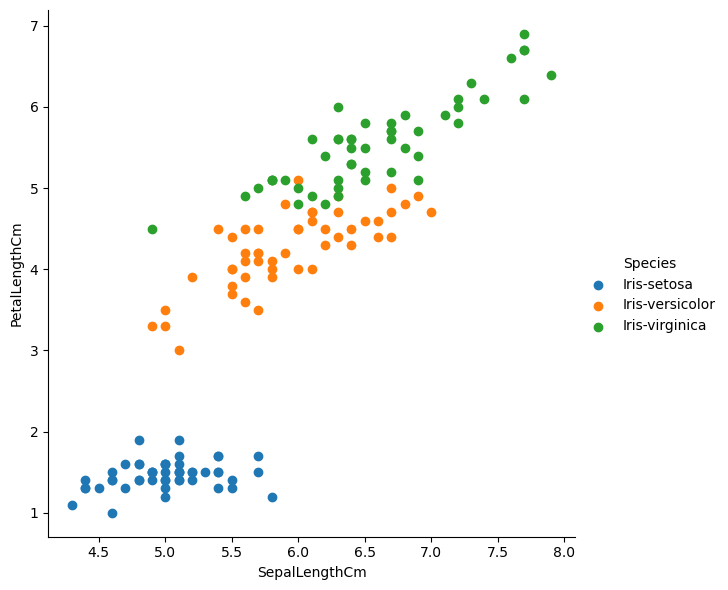

In [109]:
#Visualize Data 
sns.FacetGrid(Iris_ds, hue ="Species", 
              height = 6).map(plt.scatter, 
                              'SepalLengthCm', 
                              'PetalLengthCm').add_legend()

In [96]:
# convert 3 species into 0, 1, 2
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Iris_ds['Species'] = le.fit_transform(Iris_ds['Species'])

X = Iris_ds.drop("Species", axis = 1)
y = Iris_ds["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42)

In [97]:
y_train

84     1
148    2
53     1
5      0
93     1
      ..
71     1
106    2
14     0
92     1
102    2
Name: Species, Length: 75, dtype: int64

In [98]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [99]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [100]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [101]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {'Logistic Regression': lr, 'KNN': knn, 'Naive Bayes': nb}

for name, model in models.items():
    y_pred = model.predict(X)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y, y_pred))
    
    print("cm:", confusion_matrix(y, y_pred))

    print("classification report:", classification_report(y, y_pred))


Logistic Regression
Accuracy: 1.0
cm: [[50  0  0]
 [ 0 50  0]
 [ 0  0 50]]
classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50
           2       1.00      1.00      1.00        50

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150


KNN
Accuracy: 0.9933333333333333
cm: [[50  0  0]
 [ 0 49  1]
 [ 0  0 50]]
classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      0.98      0.99        50
           2       0.98      1.00      0.99        50

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150


Naive Bayes
Accuracy: 0.9933333333333333